In [57]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv(
    r"C:/Users/HP/OneDrive/Desktop/janseva.ai/data/updated_data.csv"
)

In [59]:
df.shape

(3400, 11)

In [60]:
df.head()

,scheme_name,slug,details,benefits,eligibility,application,documents,level,schemeCategory,Unnamed: 9,tags
0,"""Immediate Relief Assistance"" under ""Welfare a...",ira-wrflsncs,"The scheme ""Immediate Relief Assistance"" is a ...","₹ 1,00,000, in two installments of ₹ 50,000 ea...",The applicant should be the family (legal heir...,Step 1: The interested applicant should visit ...,Photograph of the Family (Legal Heir) of the M...,State,"Agriculture,Rural & Environment, Social welfar...",NaN,"Missing, Fisherman, Relief, Financial Assistan..."
1,AICTE SHORT TERM TRAINING PROGRAMME-SFURTI SCHEME,astpss,"Short Term Training Programme-SFURTI Program, ...","Financial Assistance : Limit of funding ₹ 4,00...",The institution should be AICTE approved.,Registration of New Institute: Step 01: Visit ...,Feedback Form Copy of Proceedings Completion R...,Central,Education & Learning,NaN,"Trainings, Financial Assistance, AICTE"
2,Burial and Ex-gratia Payment Scheme in Case of...,baepsicodouldwact,"Launched in 2014, the "" Burial and Ex-gratia P...","Funeral Assistance: ₹3,000 payable in case of ...",The deceased construction worker should have b...,Step 1: The interested applicant should visit ...,Aadhaar Card of the applicant (nominee/Legal h...,State,Social welfare & Empowerment,NaN,"Building Worker, Construction Workers, Unregis..."
3,Consortia & Tender Marketing Scheme,ctms,Promotion of the product of Micro and Small En...,Enlistment of the Unit for participating in Go...,Micro & Small Enterprises registered with NSIC...,"Step 01: The application form, in the prescrib...",A passport size photograph of each of the Prop...,Central,Business & Entrepreneurship,NaN,"Goods And Services Marketing, Turnkey Projects..."
4,Garuda Scheme for Funeral Expense,gsfe,Andhra Pradesh Brahmin Welfare Corporation (AB...,"Financial Assistance of ₹10,000/- for funeral ...",The applicant should be a close relative of th...,Registration and apply Step 01: Applicants hav...,Passport-size Photograph of the Applicant Aadh...,State,Social welfare & Empowerment,NaN,"Social Welfare, Financial Assistance, Deceased..."


In [61]:
df.tail

<bound method NDFrame.tail of                                             scheme_name               slug  \
0     "Immediate Relief Assistance" under "Welfare a...       ira-wrflsncs   
1     AICTE SHORT TERM TRAINING PROGRAMME-SFURTI SCHEME             astpss   
2     Burial and Ex-gratia Payment Scheme in Case of...  baepsicodouldwact   
3                   Consortia & Tender Marketing Scheme               ctms   
4                     Garuda Scheme for Funeral Expense               gsfe   
...                                                 ...                ...   
3395  “Ishan Uday” Special Scholarship Scheme For No...         iu-sss-ner   
3396  “Medical Camps (Allopathy and Indian systems o...    mcacism-giapsca   
3397                         “RAKSHAK PURASKARS’’ Award                rpa   
3398  “Training in Coir” Component of the "Developme...         ticcotdocs   
3399                ₹ 5 Lakh Insurance Cover To Farmers   farmer-insurance   

                                 

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   scheme_name     3400 non-null   str    
 1   slug            3400 non-null   str    
 2   details         3400 non-null   str    
 3   benefits        3400 non-null   str    
 4   eligibility     3400 non-null   str    
 5   application     3398 non-null   str    
 6   documents       3389 non-null   str    
 7   level           3400 non-null   str    
 8   schemeCategory  3400 non-null   str    
 9   Unnamed: 9      0 non-null      float64
 10  tags            3371 non-null   str    
dtypes: float64(1), str(10)
memory usage: 12.5 MB


removing unnecessary columns from the dataset

In [63]:
df.dtypes

scheme_name           str
slug                  str
details               str
benefits              str
eligibility           str
application           str
documents             str
level                 str
schemeCategory        str
Unnamed: 9        float64
tags                  str
dtype: object

check missing values

In [64]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing.sort_values("Missing Count", ascending=False)

,Missing Count,Missing %
Unnamed: 9,3400,100.00
tags,29,0.85
documents,11,0.32
application,2,0.06
details,0,0.00
scheme_name,0,0.00
slug,0,0.00
benefits,0,0.00
eligibility,0,0.00
schemeCategory,0,0.00


In [65]:
df["Unnamed: 9"].isna().all()

np.True_

In [66]:
df["Unnamed: 9"].isna().sum()

np.int64(3400)

In [67]:
df = df.drop(columns=["Unnamed: 9"])

In [83]:
text_columns = [
    "details",
    "benefits",
    "eligibility",
    "application",
    "documents",
    "tags"
]

df[text_columns] = df[text_columns].fillna("")

check duplicates

In [84]:
df.duplicated().sum()

np.int64(3)

In [85]:
df = df.drop_duplicates()

In [86]:
df.duplicated().sum()

np.int64(0)

Check duplicate scheme IDs/slugs

In [87]:
df["slug"].duplicated().sum()

np.int64(0)

Clean text columns

In [88]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    text = text.replace("\t", " ")
    text = text.replace("\r", " ")
    text = text.replace("\n", " ")
    
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [89]:
for col in text_columns:
    df[col] = df[col].apply(clean_text)

clean scheme_name

In [90]:
df["scheme_name"] = df["scheme_name"].str.strip()

Analyze level

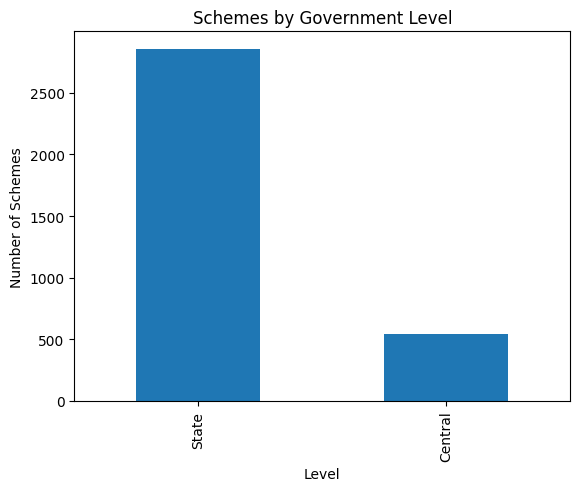

In [91]:
df["level"].value_counts().plot(kind="bar")

plt.title("Schemes by Government Level")
plt.xlabel("Level")
plt.ylabel("Number of Schemes")
plt.show()

Analyze schemeCategory

In [92]:
category_counts = df["schemeCategory"].value_counts()

category_counts.head(20)

schemeCategory
Social welfare & Empowerment                                              641
Education & Learning                                                      557
Agriculture,Rural & Environment                                           384
Business & Entrepreneurship                                               332
Social welfare & Empowerment, Women and Child                             149
Health & Wellness                                                         100
Skills & Employment                                                        94
Education & Learning, Social welfare & Empowerment                         75
Banking,Financial Services and Insurance                                   58
Housing & Shelter                                                          47
Education & Learning, Women and Child                                      46
Sports & Culture                                                           46
Social welfare & Empowerment, Education & Learnin

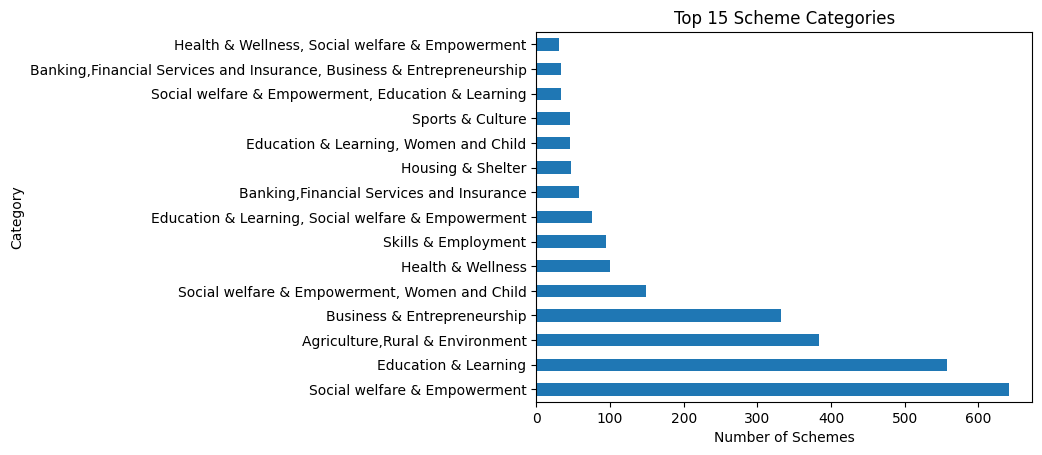

In [93]:
category_counts.head(15).plot(kind="barh")

plt.title("Top 15 Scheme Categories")
plt.xlabel("Number of Schemes")
plt.ylabel("Category")
plt.show()

investigating missing documents

In [94]:
df[df["documents"].isna()][["scheme_name", "documents"]]

,scheme_name,documents


In [95]:
df[df["tags"].isna()][["scheme_name", "tags"]]

,scheme_name,tags


In [96]:
df.duplicated().sum()

np.int64(0)

checking duplicate rows from the dataset

In [98]:
#how many different categories?
df["schemeCategory"].nunique()

210

In [99]:
#How many rows/schemes are there in each category?
df["schemeCategory"].value_counts()

schemeCategory
Social welfare & Empowerment                                                                                              641
Education & Learning                                                                                                      557
Agriculture,Rural & Environment                                                                                           384
Business & Entrepreneurship                                                                                               332
Social welfare & Empowerment, Women and Child                                                                             149
                                                                                                                         ... 
Housing & Shelter, Agriculture,Rural & Environment                                                                          1
Banking,Financial Services and Insurance, Education & Learning, Skills & Employment                    

In [100]:
category_percentage = (
    df["schemeCategory"]
    .value_counts(normalize=True)
    * 100
)

category_percentage

schemeCategory
Social welfare & Empowerment                                                                                              18.869591
Education & Learning                                                                                                      16.396821
Agriculture,Rural & Environment                                                                                           11.304092
Business & Entrepreneurship                                                                                                9.773329
Social welfare & Empowerment, Women and Child                                                                              4.386223
                                                                                                                            ...    
Housing & Shelter, Agriculture,Rural & Environment                                                                         0.029438
Banking,Financial Services and Insurance, Education & Learnin

In [101]:
df["schemeCategory"].value_counts().head(15)

schemeCategory
Social welfare & Empowerment                                             641
Education & Learning                                                     557
Agriculture,Rural & Environment                                          384
Business & Entrepreneurship                                              332
Social welfare & Empowerment, Women and Child                            149
Health & Wellness                                                        100
Skills & Employment                                                       94
Education & Learning, Social welfare & Empowerment                        75
Banking,Financial Services and Insurance                                  58
Housing & Shelter                                                         47
Education & Learning, Women and Child                                     46
Sports & Culture                                                          46
Social welfare & Empowerment, Education & Learning           

In [102]:
df["schemeCategory"].str.contains(",", na=False).sum()

np.int64(1512)

In [103]:
clean_df = df.copy()

In [104]:
clean_df = clean_df.dropna(axis=1, how="all")

In [105]:
clean_df = clean_df.drop_duplicates()

Create a final cleaned dataset

In [107]:
final_df = df.copy()

In [106]:
clean_df.to_csv(
    "../data/processed/cleaned_janseva_schemes.csv",
    index=False
)